# data generation for this script
## Synthtab
run the scripts:
* python/neuralnetmodelling/synthtab_dataprep-nofilter.ipynb for generation of the label slices, tagged with metadata regarding the audio files
* python/neuralnetmodelling/create_trainingsubset.ipynb, to generate a subset of the labels with their prefiltered audio snippets

# run this headless

conda activate guitarmidi
screen jupyter nbconvert --to notebook --execute traning.ipynb --output=output_notebook.ipynb --ExecutePreprocessor.timeout=-1



In [1]:
import re
import os
# call rsync -a --info=progress2 --no-inc-recursive /data2/training_subset /home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset
# os.system('rsync -a --info=progress2 --no-inc-recursive /data2/training_subset /home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling')
# call /home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/copy_trainingsubset.sh
# os.system('/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/copy_trainingsubset_electric.sh')
# os.system('/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/copy_trainingsubset_small.sh')







In [2]:
# title: "Data Loading and Preprocessing for Guitar Note Detection"
# overview: This block loads the dataset from TFRecord files, applies necessary parsing and filtering, and prepares it for training by batching and prefetching. It also splits the dataset into training and validation sets.
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
# NO Keras backend import needed now
import re
import common
from common import INPUT_SHAPE, OUTPUT_DIM_NOTES,feature_description,filter_polyphony,write_prefiltered_tfrecord,write_note_histogram,fast_gpu_map,parse_filtered_audio_record
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import glob # To list files
import random

BATCH_SIZE = 256
#input_data_dir = ['/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/training_subset_electric','/training_cache/training_subset_electric']#'/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training'
input_data_dir=['/data/training_subset_electric/']
input_filepaths=[]
for dir in input_data_dir:
    input_filepaths.extend(glob.glob(os.path.join(dir, '**', '*.tfrecord'), recursive=True))
input_filepaths = sorted(input_filepaths,key=lambda file: int(re.findall('\\d+',os.path.basename(file))[0]) )
#print(input_filepaths)

#input_filepaths=input_filepaths[:12000]
random.shuffle(input_filepaths)
# 

#Load the dataset from the TFRecord file
raw_dataset = tf.data.TFRecordDataset(input_filepaths)
# Function to parse the TFRecord examples

# Parse the dataset
dataset = raw_dataset.map(parse_filtered_audio_record)
#dataset=filter_polyphony(dataset,6,False)




#write_prefiltered_tfrecord(dataset, '/data2/training_subset/filtered_poly_6notes')
# print(dataset)
# Split the dataset into training and validation sets
#dataset_size =sum(1 for _ in dataset)
#dataset_size=605286
#dataset_size=12000000
dataset_size=20000000#10676000
dataset_size=len(input_filepaths)*1000 # Assuming each TFRecord file contains 1000 samples, adjust if different
#dataset_size=1424312 #2M sampleset
#dataset_size=14280596 #20M sampleset

print("The size is fixed to {dataset_size} for now, as counting the dataset size is time-consuming.",flush=True)
print("Total dataset size:", dataset_size,flush=True)
#dataset=dataset.shuffle(buffer_size=10000,reshuffle_each_iteration=True)#.shuffle(buffer_size=dataset_size)
split_ratio = 0.7
train_size = int(split_ratio * dataset_size)
train_dataset = dataset.take(train_size).shuffle(buffer_size=10000,reshuffle_each_iteration=True)
val_dataset = dataset.skip(train_size)
# Map loading function (now includes the weight vector)

train_dataset = train_dataset.map(lambda it,ot: fast_gpu_map(it,ot, training=True), num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.map(lambda it,ot: fast_gpu_map(it,ot, training=False), num_parallel_calls=tf.data.AUTOTUNE)
# # Apply batching and prefetching  (use train/val_dataset.cache().batch... if needed)
train_dataset = train_dataset.batch(BATCH_SIZE,drop_remainder=True).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE,drop_remainder=True).prefetch(tf.data.AUTOTUNE)


I0000 00:00:1777379387.964812  223696 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777379387.990439  223696 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777379388.843200  223696 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


The size is fixed to {dataset_size} for now, as counting the dataset size is time-consuming.
Total dataset size: 70821000


W0000 00:00:1777379390.013692  223696 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1777379390.033431  223696 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1777379390.145089  223696 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11408 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [3]:
write_note_histogram(train_dataset, '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/train_note_histogram.csv',37,has_filtered_audio=True)
# write_note_histogram(val_dataset, '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/val_note_histogram.csv',37,has_filtered_audio=True)

I0000 00:00:1777379390.404938  224555 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


Writing note histogram to CSV:
Note 0: 2349913
Note 1: 857653
Note 2: 946573
Note 3: 2336630
Note 4: 678134
Note 5: 4261555
Note 6: 966282
Note 7: 3998791
Note 8: 2899518
Note 9: 1719488
Note 10: 6454641
Note 11: 1234233
Note 12: 6930709
Note 13: 2340495
Note 14: 2827287
Note 15: 6652509
Note 16: 2522899
Note 17: 8194124
Note 18: 2066387
Note 19: 7011836
Note 20: 4990814
Note 21: 3545402
Note 22: 6824395
Note 23: 1945878
Note 24: 7675212
Note 25: 2502557
Note 26: 3488553
Note 27: 3719642
Note 28: 1299643
Note 29: 2525274
Note 30: 594208
Note 31: 1423574
Note 32: 809954
Note 33: 406483
Note 34: 574308
Note 35: 187510
Note 36: 486434
Note histogram written to /home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/train_note_histogram.csv


Model Architecture:
--------------------------------------------------------------------------------
Model: "guitar_note_detector"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_spectrogram   │ (256, 148, 256,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local_mean          │ (256, 148, 256,   │          0 │ input_spectrogra… │
│ (AveragePooling2D)  │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local_contrast      │ (256, 148, 256,   │          0 │ input_spectrogra… │
│ (Subtract)          │ 1)                │            │ local_mean[0][0]  │
├─────────────────────

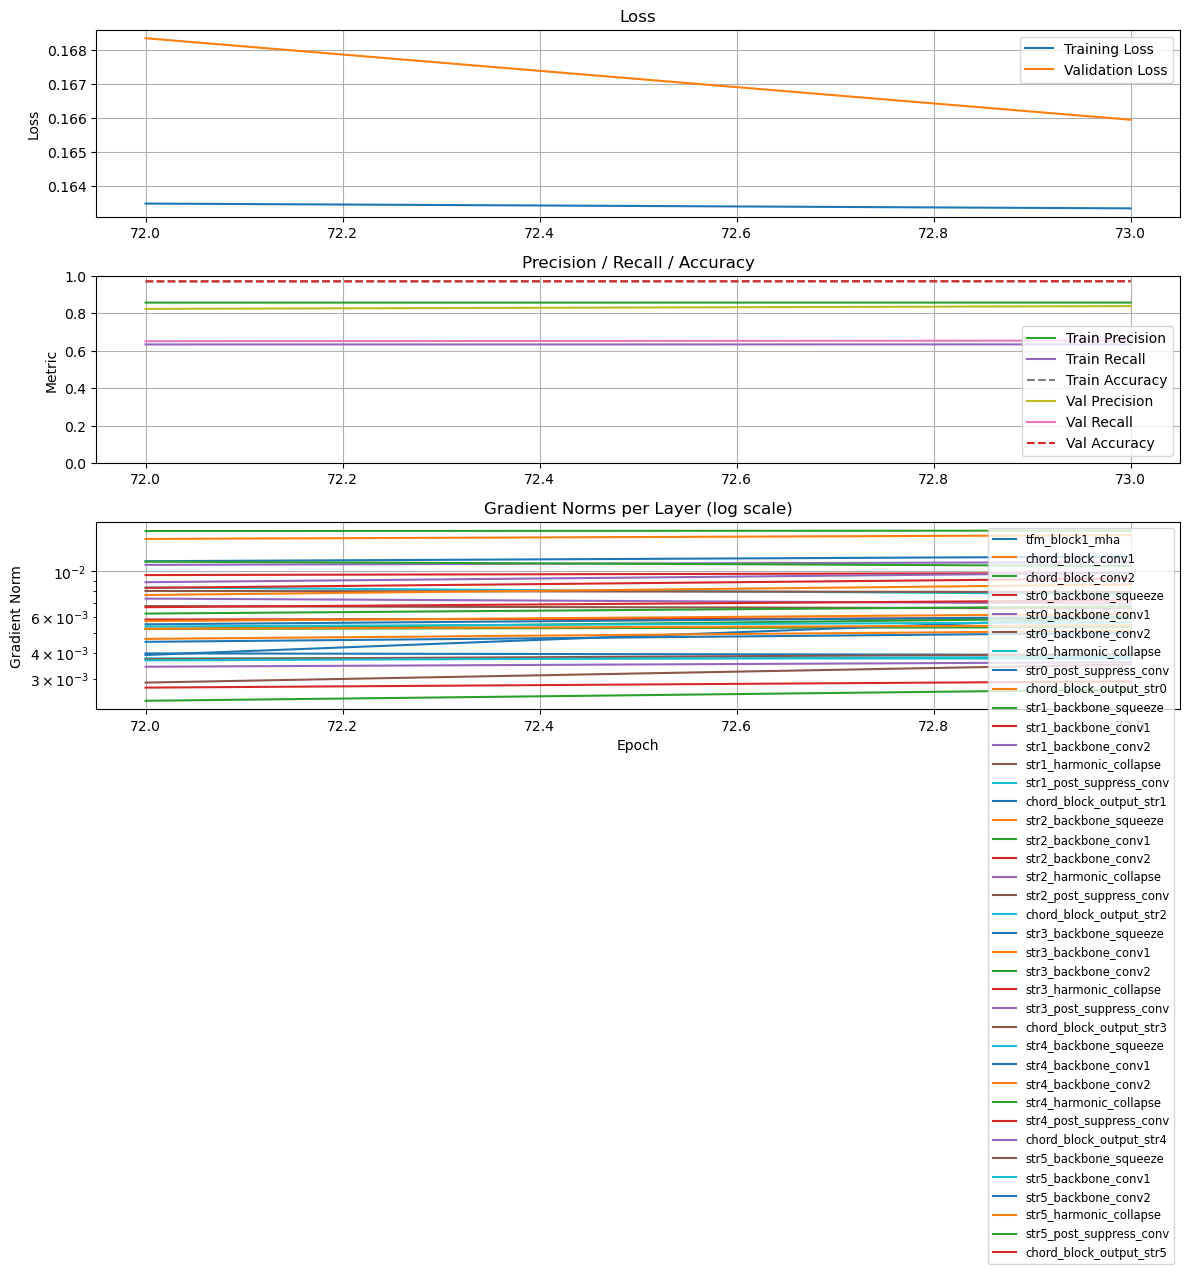

193651/193651 ━━━━━━━━━━━━━━━━━━━━ 30119s 156ms/step - bin_acc: 0.9714 - f1_score: 0.7292 - loss: 0.1634 - precision: 0.8576 - recall: 0.6342 - val_bin_acc: 0.9717 - val_f1_score: 0.7351 - val_loss: 0.1660 - val_precision: 0.8387 - val_recall: 0.6543 - learning_rate: 1.0000e-04
Epoch 74/500
193648/193651 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - bin_acc: 0.9716 - f1_score: 0.7297 - loss: 0.1632 - precision: 0.8578 - recall: 0.6349

In [ ]:
#title: "Model training with pre-filtered data  "
# overview: This block defines a simple CNN model for guitar note detection, compiles it with an appropriate loss function and metrics, 
# and trains it using the preprocessed training dataset. It also includes callbacks for early stopping and learning rate reduction based on validation performance.

#details: The model architecture is defined in a separate function (assumed to be in model.py) and is designed to take the pre-filtered input shape. 
# The loss function is a weighted binary cross-entropy that accounts for class imbalance based on the note histogram. 
# The training process includes callbacks to monitor performance and adjust learning rates or stop early if overfitting is detected.
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
# NO Keras backend import needed now
from model import build_1d_cnn_model # Assumes build_cnn_model is in model.py
import common
from common import INPUT_SHAPE, OUTPUT_DIM_NOTES,tf_load_sample_from_files,SAMPLERATE,feature_description,INPUT_SHAPE_AUDIO
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import glob # To list files
import datetime
from fretboard import FretBoard,num_frets,num_strings,num_harmonics
from scipy import signal
# --- 1. GPU Setup ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable Mixed Precision
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision policy set to 'mixed_float16'.")

        for gpu in gpus:
            # Enable memory growth
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled for GPUs.")
    except RuntimeError as e:
        print(f"Error configuring GPU: {e}")
# ---------------------------------------------------------------------------------

print(f"TensorFlow version: {tf.__version__}")

# --- 2. Configuration ---
LEARNING_RATE = 0.0001# till epoch 70
PROBABILITY_THRESHOLD = 0.6
EPOCHS = 500
print("Batch size:",BATCH_SIZE)
print("Learning rate:",LEARNING_RATE)
print("Epochs:",EPOCHS)
SAMPLES=dataset_size#
#SAMPLES=504000000000/(312*256+129) # Rough estimate of total samples in dataset
print("Estimated total samples:",SAMPLES)
STEPS_PER_EPOCH = int((SAMPLES*split_ratio) // BATCH_SIZE)
print("Steps per epoch:",STEPS_PER_EPOCH)


VALIDATION_STEPS = int((SAMPLES * (1 - split_ratio)) // BATCH_SIZE)
print("Validation steps:",VALIDATION_STEPS)
# probability in logits space corresponding to the PROBABILITY_THRESHOLD
LOGIT_THRESHOLD = np.log(PROBABILITY_THRESHOLD / (1 - PROBABILITY_THRESHOLD))
print(f"Logit threshold for probability {PROBABILITY_THRESHOLD}: {LOGIT_THRESHOLD:.4f}")
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=LEARNING_RATE,
    first_decay_steps=STEPS_PER_EPOCH * 30,  # 30 epochs per first cycle
    t_mul=2.0,                      # double cycle length each restart
    m_mul=1.0,                      # restart to same max LR (or 0.9 to decay peaks)
    alpha=1e-6                      # minimum LR
)



output_range=range(40,77) # Only keep the 37 note labels we care about
# output_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training/output'
# input_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/input'
# output_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/output'


# --- 4. Model Definition and Compilation (Using built-in loss) ---

# cnn_model = build_cnn_model(common.INPUT_SHAPE, common.OUTPUT_DIM_NOTES)
cnn_model = build_1d_cnn_model(BATCH_SIZE,common.INPUT_SHAPE, len(output_range))#common.OUTPUT_DIM_NOTES)
#load the file note_histogram.csv and create a weight vector for the loss function. Normalize the weights such that the silence label at OUTPUT_DIM_NOTES-1 has a weight of 1.0
# Total samples in dataset
import csv
TOTAL_SAMPLES = dataset_size  # or whatever your actual total is

# For each note, compute pos_weight = num_negatives / num_positives
pos_weights = np.ones(37, dtype=np.float32)

with open('/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/train_note_histogram.csv', mode='r') as csv_file:
    reader = csv.DictReader(csv_file)
    for row in reader:
        note = int(row['MIDI Note'])
        count = int(row['Count'])
        if count > 0 and note >= 0:
            neg_count = TOTAL_SAMPLES - count
            raw_weight = neg_count / count
            pos_weights[note] = raw_weight#np.clip(raw_weight, 1.0, 10.0)
        else:
            pos_weights[note] = 1.0
# normalize to minimal weight then clip to max 10.0
normalized_weights = pos_weights / np.min(pos_weights)
pos_weights = np.clip(normalized_weights, 1.0, 10.0)

# # Clip to prevent extreme values
# pos_weights = np.clip(pos_weights, 1.0, 30.0)
# pos_weights = np.clip(pos_weights / 10.0, 1.0, 3.0)

# pos_weights = pos_weights[output_range]

print("Pos weights for loss function:", pos_weights)
# #weights=weights[60:80]


# print("Class weights for loss function:", weights)
# define the weighted binary cross-entropy loss function using the weights, using label smoothing
# def get_guitar_focal_loss(gamma=5.0, alpha=0.25):
#     # Ensure weights are (1, 129) for proper broadcasting across the batch
#     note_weights = tf.constant(weights, dtype=tf.float32)
#     note_weights = tf.reshape(note_weights, (1, -1)) 
    
#     def loss_fn(y_true, y_pred):
#         # 1. Clip predictions to prevent log(0) resulting in NaN
#         epsilon = tf.keras.backend.epsilon()
#         y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        
#         # 2. Calculate standard Binary Cross Entropy per-element
#         # Shape: (Batch, 129)
#         bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        
#         # 3. Calculate Focal Term: (1 - p_t)^gamma
#         # p_t is y_pred for actual notes, and (1 - y_pred) for silence
#         p_t = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
#         focal_factor = tf.pow(1.0 - p_t, gamma)
        
#         # 4. Calculate Alpha Balancing: 
#         alpha_factor = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
        
#         # 5. Combine everything with your CSV-based note weights
#         # (Batch, 129) * (Batch, 129) * (Batch, 129) * (1, 129)
#         element_wise_loss = alpha_factor * focal_factor * bce * note_weights
        
#         # 6. Reduce to a single scalar (mean of all batch elements and all notes)
#         return tf.reduce_mean(element_wise_loss)

#     return loss_fn

def weighted_bce_loss_probs(pos_weight):
    def loss(y_true, y_pred_probs):
        # Clip probabilities to prevent log(0) which causes NaN losses
        y_pred_probs = tf.clip_by_value(y_pred_probs, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())
        
        # Calculate Weighted Binary Crossentropy manually
        # Formula: - [pos_weight * y * log(p) + (1 - y) * log(1 - p)]
        term_1 = pos_weight * y_true * tf.math.log(y_pred_probs)
        term_2 = (1.0 - y_true) * tf.math.log(1.0 - y_pred_probs)
        
        return tf.reduce_mean(-(term_1 + term_2))
        
    return loss

def get_weighted_bce(per_class_weights):
    # Ensure weights are a float32 tensor so it plays nicely with TF graphs
    weights_tensor = tf.constant(per_class_weights, dtype=tf.float32)
    
    def loss(y_true, y_pred):
        # Clip to prevent log(0)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        
        # Apply the per-class weights ONLY to the positive predictions (y_true == 1)
        # This penalizes the model more for missing rare notes, up to your max clip of 2.0
        pos_term = -y_true * tf.math.log(y_pred) * weights_tensor
        
        # The negative penalty (y_true == 0) remains standard (weight = 1.0)
        neg_term = -(1.0 - y_true) * tf.math.log(1.0 - y_pred)
        
        # Sum the terms, then take the mean over the batch
        return tf.reduce_mean(pos_term + neg_term)
        
    return loss

def weighted_bce_loss_logits(pos_weights):
    def loss(y_true, y_pred_logits):
        return tf.reduce_mean(
            tf.nn.weighted_cross_entropy_with_logits(
                labels=y_true,
                logits=y_pred_logits,
                pos_weight=pos_weights
            )
        )
    return loss
def weighted_focal_loss_logits(pos_weights, gamma=2.0, alpha=0.75):
    pos_weights = tf.constant(pos_weights, dtype=tf.float32)
    
    def loss(y_true, y_pred_logits):
        y_true = tf.cast(y_true, y_pred_logits.dtype)
        pw = tf.cast(pos_weights, y_pred_logits.dtype)
        
        bce = tf.nn.sigmoid_cross_entropy_with_logits(
            labels=y_true, logits=y_pred_logits
        )
        
        p = tf.sigmoid(y_pred_logits)
        p_t = y_true * p + (1 - y_true) * (1 - p)
        modulating = tf.pow(1.0 - p_t, gamma)
        
        # Per-class alpha weighting; pw broadcasts over batch/time dims
        alpha_t = y_true * alpha * pw + (1 - y_true) * (1 - alpha)
        
        focal = alpha_t * modulating * bce
        return tf.reduce_mean(focal)
    return loss

def guitar_loss(y_true, y_pred):
    bce_fn = weighted_bce(pos_weight=1)
    bce = bce_fn(y_true, y_pred)
    # Penalize multiple frets per string
    # Assuming your 89 outputs map to 6 strings with known fret ranges
    # offsets = [0, 5, 10, 15, 19, 24]
    string_slices = [(0, 5), (5, 10), (10, 15), (15, 19), (19, 24), (24, 37)]
    penalty = 0.0
    for start, end in string_slices:
        per_string = y_pred[:, start:end]
        # sum of probs per string should be ≤ 1
        penalty += tf.reduce_mean(tf.nn.relu(tf.reduce_sum(per_string, axis=-1) - 1.0) ** 2)
    
    return bce + 0.1 * penalty




class PlotLoss(tf.keras.callbacks.Callback):
    def __init__(self, sample_batch=None, monitor_layers=None):
        super().__init__()
        self.sample_batch = sample_batch
        self.monitor_layers = monitor_layers or [ 'tfm_block1_mha', 'chord_block_conv1', 'chord_block_conv2']

        for i in range(6):
            # monitor the string-specific layers for each string block
            prefix = f"str{i}"
            self.monitor_layers.append(f"{prefix}_backbone_squeeze")
            self.monitor_layers.append(f"{prefix}_backbone_conv1")
            self.monitor_layers.append(f"{prefix}_backbone_conv2")
            self.monitor_layers.append(f"{prefix}_harmonic_collapse")
            self.monitor_layers.append(f"{prefix}_post_suppress_conv")
            name_prefix = f"chord_block"
            self.monitor_layers.append(f"{name_prefix}_output_str{i}")
        
    def on_train_begin(self, logs=None):
        self.losses = []
        self.val_losses = []
        self.acc = []
        self.val_bin_acc = []
        self.precision = []
        self.val_precision = []
        self.recall = []
        self.val_recall = []
        self.epochs_run = []
        # Gradient tracking: {layer_name: [norm_per_epoch]}
        self.grad_norms = {name: [] for name in self.monitor_layers}
        self.weight_norms = {name: [] for name in self.monitor_layers}
        
        self.fig = None
        summary_list = []
        self.model.summary(print_fn=lambda x: summary_list.append(x))
        self.model_summary = '\n'.join(summary_list)
        with open('model_summary.txt', 'w') as f:
            f.write(self.model_summary)

    def _compute_gradients(self):
        if self.sample_batch is None:
            return
        sample_x, sample_y = self.sample_batch
        
        with tf.GradientTape() as tape:
            preds = self.model(sample_x, training=True)
            loss = self.model.compiled_loss(sample_y, preds)
        
        grads = tape.gradient(loss, self.model.trainable_variables)
        
        # Accumulate gradient norms per monitored layer
        layer_grads = {name: 0.0 for name in self.monitor_layers}
        layer_weights = {name: 0.0 for name in self.monitor_layers}
        layer_counts = {name: 0 for name in self.monitor_layers}
        
        for var, grad in zip(self.model.trainable_variables, grads):
            if grad is None:
                continue
            for name in self.monitor_layers:
                var_id = getattr(var, 'path', var.name)
                if name in var_id:
                    layer_grads[name] += tf.norm(grad).numpy()
                    layer_weights[name] += tf.norm(var).numpy()
                    layer_counts[name] += 1
                    break
        
        for name in self.monitor_layers:
            c = max(layer_counts[name], 1)
            self.grad_norms[name].append(layer_grads[name] / c)
            self.weight_norms[name].append(layer_weights[name] / c)

    def on_epoch_end(self, epoch, logs=None):
        from IPython.display import display, Image, clear_output
        
        logs = logs or {}
        self.epochs_run.append(epoch + 1)
        
        self.losses.append(float(logs.get('loss', np.nan)))
        self.val_losses.append(float(logs.get('val_loss', np.nan)))
        
        acc_val = logs.get('accuracy') or logs.get('acc') or logs.get('bin_acc')
        val_bin_acc_val = logs.get('val_bin_acc')
        self.acc.append(float(acc_val) if acc_val is not None else np.nan)
        self.val_bin_acc.append(float(val_bin_acc_val) if val_bin_acc_val is not None else np.nan)
        
        self.precision.append(float(logs.get('precision', np.nan)))
        self.val_precision.append(float(logs.get('val_precision', np.nan)))
        self.recall.append(float(logs.get('recall', np.nan)))
        self.val_recall.append(float(logs.get('val_recall', np.nan)))
        
        # Compute gradient norms
        self._compute_gradients()
        
        clear_output(wait=True)
        print("Model Architecture:")
        print("-" * 80)
        print(self.model_summary)
        print("-" * 80)
        
        # Print gradient table
        if self.sample_batch is not None:
            print("\n--- Gradient Norms (avg per layer) ---")
            print(f"  {'Layer':<30s}  {'Grad Norm':>12s}  {'Weight Norm':>12s}  {'Ratio':>12s}")
            for name in self.monitor_layers:
                if self.grad_norms[name]:
                    gn = self.grad_norms[name][-1]
                    wn = self.weight_norms[name][-1]
                    ratio = gn / wn if wn > 0 else float('inf')
                    print(f"  {name:<30s}  {gn:>12.6f}  {wn:>12.6f}  {ratio:>12.8f}")
            print("-" * 80)
        
        # 3 subplots now: loss, metrics, gradients
        if self.fig is not None:
            plt.close(self.fig)
        self.fig, (self.ax_loss, self.ax_acc, self.ax_grad) = plt.subplots(3, 1, figsize=(12, 12))
        
        # Loss subplot
        self.ax_loss.plot(self.epochs_run, self.losses, label='Training Loss', color='tab:blue')
        if any(not np.isnan(v) for v in self.val_losses):
            self.ax_loss.plot(self.epochs_run[:len(self.val_losses)], self.val_losses, label='Validation Loss', color='tab:orange')
        self.ax_loss.set_ylabel('Loss')
        self.ax_loss.legend(loc='upper right')
        self.ax_loss.grid(True)
        self.ax_loss.set_title('Loss')
        
        # Metrics subplot
        self.ax_acc.plot(self.epochs_run, self.precision, label='Train Precision', color='tab:green')
        self.ax_acc.plot(self.epochs_run, self.recall, label='Train Recall', color='tab:purple')
        if any(not np.isnan(v) for v in self.acc):
            self.ax_acc.plot(self.epochs_run, self.acc, label='Train Accuracy', color='tab:gray', linestyle='--')
        if any(not np.isnan(v) for v in self.val_precision):
            self.ax_acc.plot(self.epochs_run[:len(self.val_precision)], self.val_precision, label='Val Precision', color='tab:olive')
        if any(not np.isnan(v) for v in self.val_recall):
            self.ax_acc.plot(self.epochs_run[:len(self.val_recall)], self.val_recall, label='Val Recall', color='tab:pink')
        if any(not np.isnan(v) for v in self.val_bin_acc):
            self.ax_acc.plot(self.epochs_run[:len(self.val_bin_acc)], self.val_bin_acc, label='Val Accuracy', color='tab:red', linestyle='--')
        self.ax_acc.set_ylabel('Metric')
        self.ax_acc.set_ylim(0.0, 1.0)
        self.ax_acc.legend(loc='lower right')
        self.ax_acc.grid(True)
        self.ax_acc.set_title('Precision / Recall / Accuracy')
        
        # Gradient norms subplot
        colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:cyan']
        for i, name in enumerate(self.monitor_layers):
            if self.grad_norms[name]:
                self.ax_grad.plot(self.epochs_run[:len(self.grad_norms[name])], 
                                  self.grad_norms[name], 
                                  label=name, color=colors[i % len(colors)])
        self.ax_grad.set_xlabel('Epoch')
        self.ax_grad.set_ylabel('Gradient Norm')
        self.ax_grad.set_yscale('log')
        self.ax_grad.legend(loc='upper right', fontsize='small')
        self.ax_grad.grid(True)
        self.ax_grad.set_title('Gradient Norms per Layer (log scale)')
        
        self.fig.tight_layout()
        self.fig.savefig("training.png", bbox_inches='tight')
        display(Image("training.png"))
        plt.close(self.fig)


# --- 6. Data Loading and Preparation (Modified to include weights) ---

print(f"Found {dataset_size} files on disk.")



















# train_dataset = batch_with_weights(train_dataset).prefetch(tf.data.AUTOTUNE)
# val_dataset = batch_with_weights(val_dataset).prefetch(tf.data.AUTOTUNE)


sample_batch = next(iter(train_dataset))
plot_callback = PlotLoss(
    sample_batch=sample_batch
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

# Use a custom learning rate scheduler
def lr_scheduler(epoch, lr):
    warmup_epochs = 5
    max_lr = 0.001
    
    if epoch < warmup_epochs:
        # Gradually increase LR from 1e-5 to 1e-3
        return 1e-4 + (max_lr - 1e-4) * (epoch / warmup_epochs)
    else:
        # Cosine Decay or stick to 1e-3 until plateau
        return lr

lr_scheduler_callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)
checkpoint=ModelCheckpoint('checkpoints/guitarmidi_staticmapping_epoch{epoch:02d}_valAcc{val_bin_acc:.4f}_valPrec{val_precision:.4f}_valRecall{val_recall:.4f}.keras', save_weights_only=False,save_freq='epoch')
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir,
        histogram_freq=1,  # Log weight histograms every epoch
        write_graph=True,
        write_images=True,
        update_freq='epoch',
        profile_batch='10,20',  # Profile batches 10-20 for performance analysis
        embeddings_freq=1)

class OverfitEarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, patience=10, min_gap=0.005):
        """
        patience: how many consecutive epochs val_loss > train_loss + min_gap before stopping
        min_gap: minimum gap between val and train loss to count as overfitting
        """
        super().__init__()
        self.patience = patience
        self.min_gap = min_gap
        self.counter = 0
        self.best_weights = None
        self.best_val_loss = float('inf')

    def on_epoch_end(self, epoch, logs=None):
        train_loss = logs.get('loss')
        val_loss = logs.get('val_loss')
        gap = val_loss - train_loss

        # Save best weights based on val_loss
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.best_weights = self.model.get_weights()
            self.counter = 0
        
        if gap > self.min_gap:
            self.counter += 1
            print(f'\n⚠️ Overfit detected: gap={gap:.5f} ({self.counter}/{self.patience})')
        else:
            self.counter = 0

        if self.counter >= self.patience:
            print(f'\n🛑 Stopping: val_loss > train_loss + {self.min_gap} for {self.patience} consecutive epochs')
            self.model.set_weights(self.best_weights)
            self.model.stop_training = True
overfit_early_stopping_callback = OverfitEarlyStopping(patience=15, min_gap=0.01)
# initial_learning_rate = LEARNING_RATE
# warmup_epochs = 5

# class WarmUpLearningRateScheduler(tf.keras.callbacks.Callback):
#     def __init__(self, warmup_epochs, initial_lr):
#         super().__init__()
#         self.warmup_epochs = warmup_epochs
#         self.initial_lr = initial_lr
        
#     def on_epoch_begin(self, epoch, logs=None):
#         if epoch < self.warmup_epochs:
#             lr = self.initial_lr * ((epoch + 1) / self.warmup_epochs)
#             tf.keras.backend.set_value(self.model.optimizer.learning_rate, lr)
#             print(f'\nEpoch {epoch+1}: WarmUp LR set to {lr}')

# warmup = WarmUpLearningRateScheduler(warmup_epochs, initial_learning_rate)

print("\n--- Starting CNN Model Training with Sample Weights ---")
try:
    # load weights from training with 2M sampleset
    cnn_model.load_weights('/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/guitarmidi.keras',skip_mismatch=True)
    #cnn_model.load_weights('/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/checkpoints/guitarmidi_epoch272_valAcc0.9688_valPrec0.8163_valRecall0.6706.h5',by_name=True, skip_mismatch=True)
    #cnn_model.load_weights('/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/checkpoints/guitarmidi_staticmapping_epoch48_valAcc0.9717_valPrec0.8216_valRecall0.6446.keras', skip_mismatch=True)
    # Keras expects (features, labels, sample_weights) when sample_weights are present
    cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0,weight_decay=1e-4),
    loss=weighted_bce_loss_probs(pos_weights),#get_weighted_bce(weights),#weighted_bce(2),
    #loss=guitar_loss,#get_guitar_focal_loss(),#
    #loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.0), # Pass the class weights here
    #loss=tf.keras.losses.BinaryFocalCrossentropy(apply_class_balancing=True,alpha=0.75,gamma=2.0,from_logits=False,label_smoothing=0.0),#,alpha=0.75, gamma=5.0, label_smoothing=0.0), # Focal loss with class balancing and label smoothing
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='bin_acc', threshold=PROBABILITY_THRESHOLD),
        tf.keras.metrics.Precision(name='precision', thresholds=PROBABILITY_THRESHOLD),
        tf.keras.metrics.Recall(name='recall', thresholds=PROBABILITY_THRESHOLD),
        tf.keras.metrics.F1Score(average='micro', threshold=PROBABILITY_THRESHOLD, name='f1_score')
    ],
    jit_compile=True
    )

    
    # for layer in cnn_model.layers:
    #     layer.trainable = 'chord_block_output' in layer.name
    cnn_model.summary()
    history_cnn = cnn_model.fit(train_dataset,
                                initial_epoch=71,#142, 
                                epochs=EPOCHS,
                                # steps_per_epoch=STEPS_PER_EPOCH,
                                # validation_steps=VALIDATION_STEPS,
                                #batch_size=BATCH_SIZE, shuffle=False,
                                validation_data=val_dataset,
                                callbacks=[plot_callback, early_stopping_callback,checkpoint,reduce_lr,tensorboard_callback])#,lr_scheduler_callback])
    
    #cnn_model.save_weights('guitarmidi.weights.keras')
    cnn_model.save('guitarmidi.keras')
    print("Model weights saved successfully!")
    
except Exception as e:
    print(f"An error occurred during training: {e}")

In [ ]:
from tensorflow.data import Dataset
dataset = Dataset.range(1, 6)  # ==> [ 1, 2, 3, 4, 5 ]
# NOTE: New lines indicate "block" boundaries.
dataset = dataset.interleave(
  lambda x: Dataset.from_tensors(x).repeat(6),
    cycle_length=2, block_length=4)
list(dataset.as_numpy_iterator())

[np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(3),
 np.int64(3),
 np.int64(3),
 np.int64(3),
 np.int64(4),
 np.int64(4),
 np.int64(4),
 np.int64(4),
 np.int64(3),
 np.int64(3),
 np.int64(4),
 np.int64(4),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5)]

In [ ]:
# import os
# os.system("sleep 10")
# os.system("poweroff")

In [ ]:
import os
os.system("sleep 10")
os.system("poweroff")